In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wfdb matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have p

Import and configure modules

In [ ]:
# import the necessary modules
import pandas as pd
import numpy as np
import os
#waveform-database:A library of tools for reading, writing, and processing WFDB signals and annotations.
import wfdb
import matplotlib as mlp
import matplotlib.pyplot as plt

LOAD A SAMPLE SIGNAL i.e 100

An example of a normal heart beat

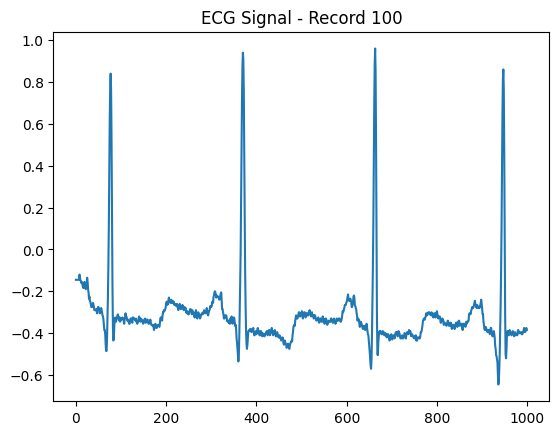

In [ ]:
path = "/content/drive/MyDrive/mitbih/data/100"
record = wfdb.rdrecord(path)
annotation = wfdb.rdann(path, 'atr')
plt.plot(record.p_signal[:1000, 0])
plt.title("ECG Signal - Record 100")
plt.show()

An example of abnormal heart beat

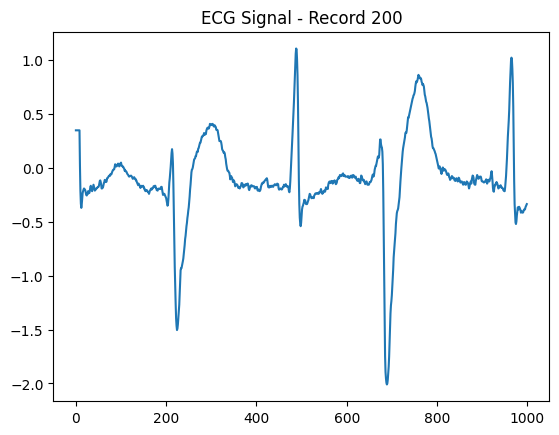

In [ ]:
path = "/content/drive/MyDrive/mitbih/data/200"
record = wfdb.rdrecord(path)
annotation = wfdb.rdann(path, 'atr')
plt.plot(record.p_signal[:1000, 0])
plt.title("ECG Signal - Record 200")
plt.show()

Importing and Preapring Data

In [ ]:
DATA_PATH = "/content/drive/MyDrive/mitbih/data"

In [ ]:
print(os.listdir(DATA_PATH))

['104.xws', '101.dat', '106.xws', '101.atr', '101.hea', '102.xws', '101.xws', '103.xws', '100.xws', '107.dat', '104.dat', '104.hea', '103.dat', '105.dat', '108.dat', '103.hea', '105.xws', '103.atr', '106.atr', '107.hea', '104.atr', '108.atr', '107.xws', '102-0.atr', '107.atr', '102.dat', '106.hea', '100.dat', '105.atr', '100.hea', '100.atr', '108.at_', '102.hea', '106.dat', '105.hea', '102.atr', '122.atr', '116.atr', '116.dat', '114.atr', '115.atr', '112.atr', '112.dat', '117.atr', '109.dat', '115.hea', '117.dat', '118.dat', '111.xws', '112.xws', '116.xws', '114.hea', '121.hea', '113.xws', '115.dat', '118.atr', '119.dat', '119.atr', '118.xws', '111.atr', '111.hea', '109.atr', '119.at_', '117.hea', '113.atr', '113.dat', '119.hea', '108.xws', '114.dat', '109.xws', '116.hea', '109.hea', '121.atr', '121.xws', '117.xws', '118.hea', '117.at_', '113.hea', '115.xws', '111.dat', '114.xws', '112.hea', '108.hea', '121.dat', '119.xws', '205.hea', '122.xws', '208.hea', '208.dat', '123.xws', '123.he

In [ ]:
# RECORDS file contains all the record names of the corresponding patients
records = np.loadtxt(os.path.join(DATA_PATH,"RECORDS"), dtype=str)
print(records)
print(len(records))

['100' '101' '102' '103' '104' '105' '106' '107' '108' '109' '111' '112'
 '113' '114' '115' '116' '117' '118' '119' '121' '122' '123' '124' '200'
 '201' '202' '203' '205' '207' '208' '209' '210' '212' '213' '214' '215'
 '217' '219' '220' '221' '222' '223' '228' '230' '231' '232' '233' '234']
48


In [ ]:
def read_data(data_path, records):
    dataset = []

    for record in records:
        record_path = os.path.join(data_path, record)
        temp = wfdb.rdrecord(record_path)
        dataset.append(temp.p_signal)

    return dataset

In [ ]:
dataset = read_data(DATA_PATH, records)

Valid and Invalid beats

In [ ]:
invalid_beat = [
    "[", "!", "]", "x", "(", ")", "p", "t",
    "u", "`", "'", "^", "|", "~", "+", "s",
    "T", "*", "D", "=",'"', "@", "B", "a", "J", "S",
    "r", "F", "e", "j", "n", "f", "Q", "?"
]

label_beats=[
    "A", "L", "/", "V", "R", "E", "N"
]

Beat Segmentation

In [ ]:
def classify(symbol):
    return 1 if symbol in label_beats else 0


def segment(signal_MLII, beat_loc, window=180):
    x = beat_loc - window
    y = beat_loc + window
    return signal_MLII[x:y]


all_signals = []
all_labels = []

for record in records:

    record_path = os.path.join(DATA_PATH, record)

    temp = wfdb.rdrecord(record_path)
    annot_temp = wfdb.rdann(record_path, 'atr')

    signal_MLII = temp.p_signal[:, 0]
    ann_sample = annot_temp.sample
    ann_symbol = annot_temp.symbol

    for i, peak in enumerate(ann_sample):

        if classify(ann_symbol[i]) == 1:

            seg = segment(signal_MLII, peak)

            # boundary check
            if len(seg) == 360:
                all_signals.append(seg)
                all_labels.append(ann_symbol[i])


In [ ]:
# vstack Stacks arrays in sequence vertically(row wise)
all_signals_fin=np.vstack(all_signals)

In [ ]:
print(all_signals_fin.shape)

(107141, 360)


Visualizing Segmentated Data

N


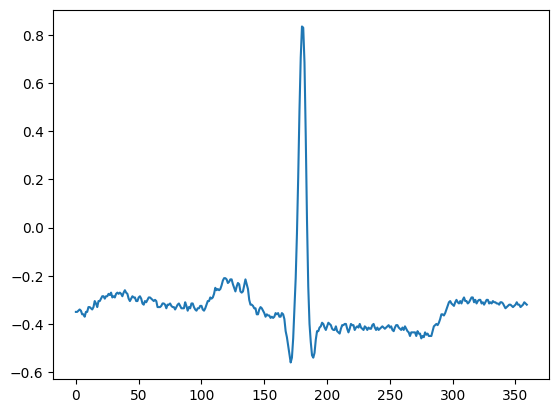

In [ ]:
#PLotting
plt.plot(all_signals_fin[187])
print(all_labels[187])

In [ ]:
import pandas as pd
labels_fin=pd.Series(all_labels)

In [ ]:
for i, value in enumerate(labels_fin):
    if value=='E':
        print(value)
        print(i)
        break

E
60641


Text(0.5, 1.0, 'Ventricular Escape Beat')

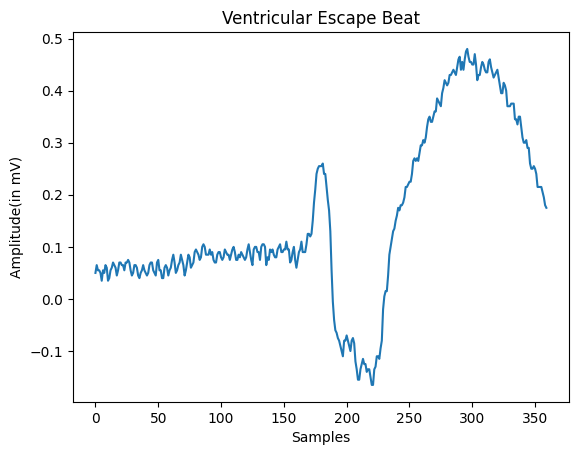

In [ ]:
plt.plot(all_signals_fin[60641])
plt.xlabel('Samples')
plt.ylabel('Amplitude(in mV)')
plt.title('Ventricular Escape Beat')

Check distribution of types of data

In [ ]:
labels_fin.value_counts()

N    75011
L     8071
R     7255
V     7129
/     7023
A     2546
E      106
Name: count, dtype: int64

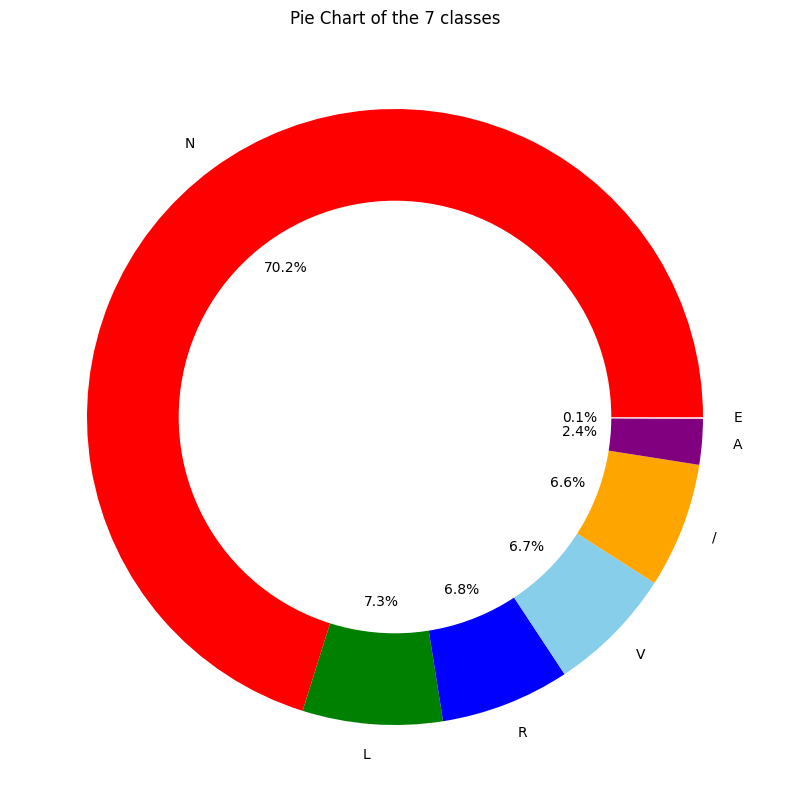

In [ ]:
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie([70.01, 7.33, 6.77, 6.65, 6.56, 2.38, 0.10], labels=['N','L','R','V','/', 'A', 'E'], colors=['red','green','blue','skyblue','orange', 'purple', 'pink'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Pie Chart of the 7 classes")
plt.show()

Resampling

In [ ]:
len(all_signals_fin)
labels_array=np.array(all_labels)

In [ ]:
df_0=all_signals_fin[labels_fin=='/']
df_1=all_signals_fin[labels_fin=='A']
df_2=all_signals_fin[labels_fin=='E']
df_3=all_signals_fin[labels_fin=='L']
df_4=all_signals_fin[labels_fin=='N']
df_5=all_signals_fin[labels_fin=='R']
df_6=all_signals_fin[labels_fin=='V']
y_df0=labels_array[labels_fin=='/']
print(len(df_0))
print(y_df0)
len(y_df0)

7023
['/' '/' '/' ... '/' '/' '/']


7023

In [ ]:
from sklearn.utils import resample

In [ ]:
df0_sampled=resample(df_0, replace=True, n_samples=20000, random_state=42)
df1_sampled=resample(df_1, replace=True, n_samples=20000, random_state=42)
df2_sampled=resample(df_2, replace=True, n_samples=20000, random_state=42)
df3_sampled=resample(df_3, replace=True, n_samples=20000, random_state=42)
df4_sampled=resample(df_4, replace=True, n_samples=20000, random_state=42)
df5_sampled=resample(df_5, replace=True, n_samples=20000, random_state=42)
df6_sampled=resample(df_6, replace=True, n_samples=20000, random_state=42)

In [ ]:
y_0=['/']*len(df0_sampled)
y_1=['A']*len(df1_sampled)
y_2=['E']*len(df2_sampled)
y_3=['L']*len(df3_sampled)
y_4=['N']*len(df4_sampled)
y_5=['R']*len(df5_sampled)
y_6=['V']*len(df6_sampled)

In [ ]:
X_final=[]
X_final.extend(df0_sampled)
X_final.extend(df1_sampled)
X_final.extend(df2_sampled)
X_final.extend(df3_sampled)
X_final.extend(df4_sampled)
X_final.extend(df5_sampled)
X_final.extend(df6_sampled)

In [ ]:
print(len(X_final))

140000


In [ ]:
y_final=[]
y_final.extend(y_0)
y_final.extend(y_1)
y_final.extend(y_2)
y_final.extend(y_3)
y_final.extend(y_4)
y_final.extend(y_5)
y_final.extend(y_6)

In [ ]:
len(y_final)

140000

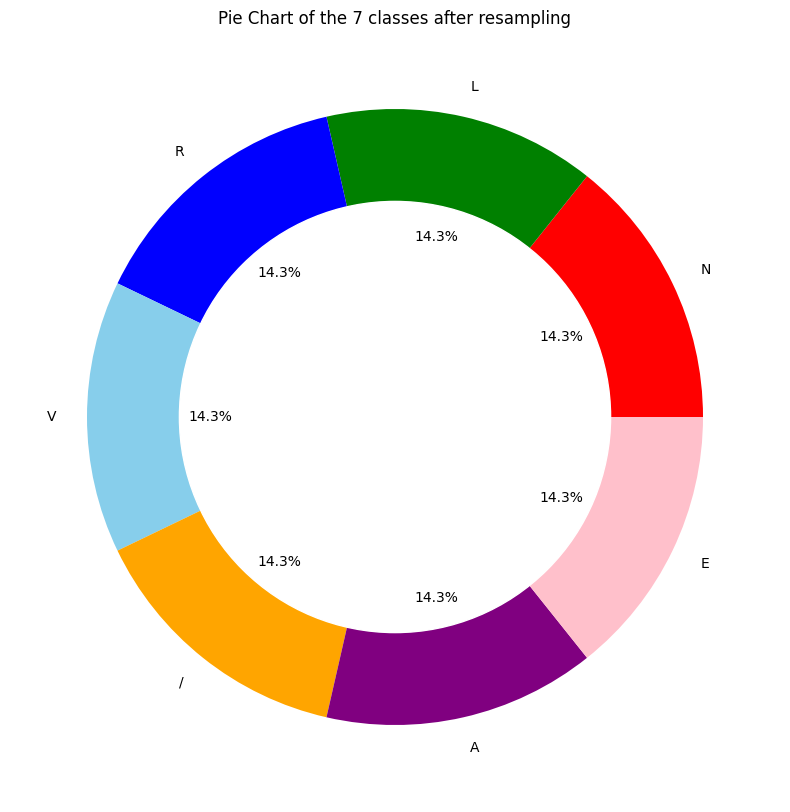

In [ ]:
plt.figure(figsize=(20,10))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie([14.29, 14.29, 14.29, 14.29, 14.29, 14.29, 14.29], labels=['N','L','R','V','/', 'A', 'E'], colors=['red','green','blue','skyblue','orange', 'purple', 'pink'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Pie Chart of the 7 classes after resampling")
plt.show()

Standarization of the data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
scaled=scaler.fit_transform(X_final)

In [ ]:
def check_strat(y):
    dummy = pd.DataFrame(y,columns=["Labels"])
    print("Value distribution:\n")
    count = dummy["Labels"].value_counts()
    percent = dummy["Labels"].value_counts(normalize=True).mul(100).round(2)
    print(pd.concat([count,percent],axis=1,keys=["Counts","Percent"]))

Splitting Data into Train and Test Set

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
strad=StratifiedShuffleSplit()

In [ ]:
assin_strad=strad.split(scaled, y_final)

In [ ]:
train_index, test_index=next(assin_strad)

In [ ]:
train_data_scaled=scaled[train_index]

In [ ]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()

In [ ]:
labels_final=lab.fit_transform(y_final)

In [ ]:
lab.classes_

array(['/', 'A', 'E', 'L', 'N', 'R', 'V'], dtype='<U1')

In [ ]:
train_label=labels_final[train_index]

In [ ]:
assin_val=strad.split(train_data_scaled, train_label)

In [ ]:
train_index_fin, val_index=next(assin_val)

In [ ]:
X_val=train_data_scaled[val_index]

In [ ]:
train_data_scaled_fin=train_data_scaled[train_index_fin]

In [ ]:
train_labels_fin=train_label[train_index_fin]

In [ ]:
y_val=train_label[val_index]

In [ ]:
test_data_scaled=scaled[test_index]

In [ ]:
test_labels=labels_final[test_index]

In [ ]:
check_strat(test_labels)

Value distribution:

        Counts  Percent
Labels                 
1         2000    14.29
5         2000    14.29
3         2000    14.29
6         2000    14.29
0         2000    14.29
2         2000    14.29
4         2000    14.29


In [ ]:
check_strat(train_label)

Value distribution:

        Counts  Percent
Labels                 
6        18000    14.29
2        18000    14.29
4        18000    14.29
5        18000    14.29
0        18000    14.29
3        18000    14.29
1        18000    14.29


In [ ]:
check_strat(y_val)

Value distribution:

        Counts  Percent
Labels                 
0         1800    14.29
2         1800    14.29
1         1800    14.29
5         1800    14.29
4         1800    14.29
3         1800    14.29
6         1800    14.29


CNN

In [ ]:
import os
import pickle

MAIN_PATH = "/content/drive/MyDrive/mitbih"

MODEL_PATH = os.path.join(MAIN_PATH, "saved_models")
os.makedirs(MODEL_PATH, exist_ok=True)

def save_model(name, model, extension=".pickle"):
    path = os.path.join(MODEL_PATH, name + extension)
    print("Saving Model:", path)

    with open(path, "wb") as file:
        pickle.dump(model, file)


In [ ]:
from tensorflow import keras
CNN_X_train=train_data_scaled_fin.reshape(len(train_data_scaled_fin), len(train_data_scaled_fin[0]), 1)
CNN_val=X_val.reshape(len(X_val), len(X_val[0]), 1)

In [ ]:
from tensorflow import keras

CNN_model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation="relu", input_shape=(360,1)),
    keras.layers.MaxPool1D(pool_size=2),

    keras.layers.Conv1D(32, kernel_size=3, activation="relu"),
    keras.layers.MaxPool1D(pool_size=2),

    keras.layers.Flatten(),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(7, activation="softmax")
])

loss = keras.losses.SparseCategoricalCrossentropy()
opt = keras.optimizers.Adam(learning_rate=0.0001)

CNN_model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

CNN_model.summary()

history = CNN_model.fit(
    CNN_X_train,
    train_labels_fin,
    epochs=20,
    batch_size=50,
    validation_data=(CNN_val, y_val)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 358, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 179, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 177, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 88, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       281,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,839 (1.10 MB)

 Trainable params: 288,839 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9071 - loss: 0.3278 - val_accuracy: 0.9624 - val_loss: 0.1296
Epoch 2/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9666 - loss: 0.1184 - val_accuracy: 0.9763 - val_loss: 0.0915
Epoch 3/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9758 - loss: 0.0857 - val_accuracy: 0.9807 - val_loss: 0.0677
Epoch 4/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9802 - loss: 0.0702 - val_accuracy: 0.9865 - val_loss: 0.0540
Epoch 5/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9833 - loss: 0.0583 - val_accuracy: 0.9756 - val_loss: 0.0854
Epoch 6/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9848 - loss: 0.0536 - val_accuracy: 0.9874 - val_loss: 0.0456
Epoch 7/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9870 - loss: 0.0449 - val_accuracy: 0.9816 - val_loss: 0.0522
Epoch 8/20
2268/2268 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9882 - loss: 0

In [ ]:
import joblib

# after training model
joblib.dump(CNN_model, "model.pkl")

['model.pkl']

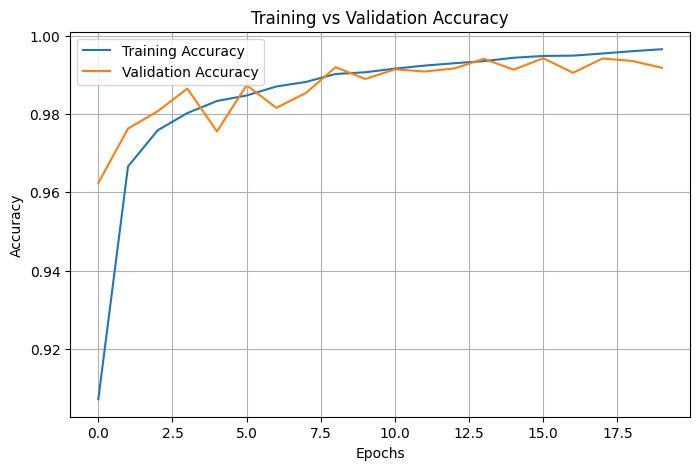

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

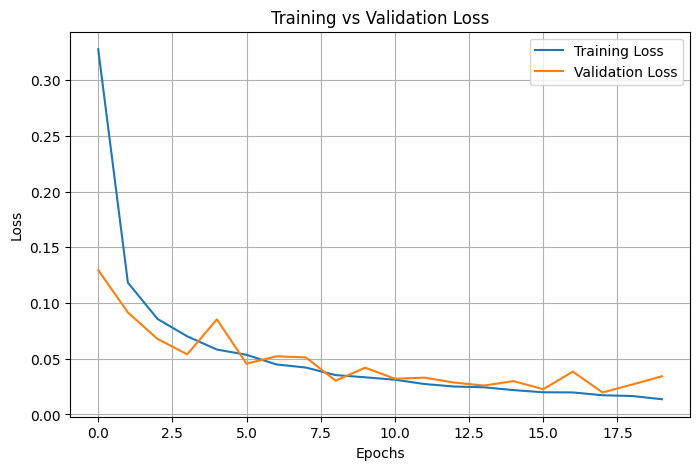

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1800
           1       0.97      1.00      0.98      1800
           2       1.00      1.00      1.00      1800
           3       1.00      0.99      0.99      1800
           4       1.00      0.96      0.98      1800
           5       1.00      1.00      1.00      1800
           6       0.99      1.00      0.99      1800

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



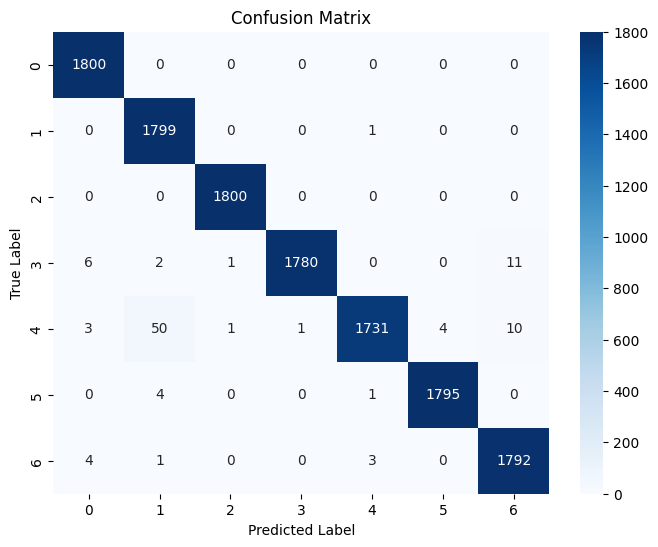

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


y_pred_probs = CNN_model.predict(CNN_val)
y_pred = np.argmax(y_pred_probs, axis=1)


if len(y_val.shape) == 1:
    y_true = y_val
else:

    y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)


print("Classification Report:\n")
print(classification_report(y_true, y_pred))


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
